In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [16]:
AUTO_ACCEPT_PD = 0.0250
AUTO_DECLINE_PD = 0.0350

REVIEW_ACCURACY = 0.98
RANDOM_SEED = 20261005

print(f"Auto accept: PD < {AUTO_ACCEPT_PD:.2%}")
print(
    f"Refer: {AUTO_ACCEPT_PD:.2%} "
    f"≤ PD ≤ {AUTO_DECLINE_PD:.2%}"
)
print(f"Decline: PD > {AUTO_DECLINE_PD:.2%}")

Auto accept: PD < 2.50%
Refer: 2.50% ≤ PD ≤ 3.50%
Decline: PD > 3.50%


---

# Opening the data from the TTD sample

In [17]:
from pathlib import Path
import pandas as pd

# Locate the project from the notebook's current working directory.
project_root = next(
    (
        folder
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / "src" / "origination_scorecard" / "generator.py").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Could not locate the Origination-Scorecard project "
        f"from {Path.cwd()}"
    )

# Load the cleaned file created by the cleaning cells.
ttd_file = (
    project_root
    / "data"
    / "TTD Modelling"
    / "TTD retrospective scored clean.csv"
)

if not ttd_file.is_file():
    raise FileNotFoundError(
        f"Clean TTD sample not found: {ttd_file}\n"
        "Run the cleaning and save cells first."
    )

policy_sample = pd.read_csv(
    ttd_file,
    dtype={"account_id": "string"},
    parse_dates=["application_date"],
)

# Notebook 16 names the actual outcome observed_bad.
policy_sample["kigb_bad"] = policy_sample["observed_bad"].astype(int)

print(f"Loaded {len(policy_sample):,} TTD accounts from:")
print(ttd_file)

Loaded 2,000 TTD accounts from:
c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\TTD Modelling\TTD retrospective scored clean.csv


In [18]:
# Use the full-precision PD for decisions; do not round it first.
policy_sample["policy_band"] = np.select(
    [
        policy_sample["predicted_pd"] < AUTO_ACCEPT_PD,
        policy_sample["predicted_pd"].between(
            AUTO_ACCEPT_PD,
            AUTO_DECLINE_PD,
            inclusive="both",
        ),
        policy_sample["predicted_pd"] > AUTO_DECLINE_PD,
    ],
    [
        "1. Auto accept",
        "2. Human review",
        "3. Auto decline",
    ],
    default="Unassigned",
)

if policy_sample["policy_band"].eq("Unassigned").any():
    raise ValueError(
        "Some applicants were not assigned to a policy band. "
        "Check predicted_pd for missing or invalid values."
    )

policy_sample["initial_decision"] = policy_sample["policy_band"].map({
    "1. Auto accept": "Accept",
    "2. Human review": "Review",
    "3. Auto decline": "Decline",
})

display(
    policy_sample["policy_band"]
    .value_counts()
    .reindex([
        "1. Auto accept",
        "2. Human review",
        "3. Auto decline",
    ], fill_value=0)
    .rename_axis("Policy band")
    .reset_index(name="Accounts")
)

,Policy band,Accounts
0,1. Auto accept,364
1,2. Human review,718
2,3. Auto decline,918


In [19]:
# Find DataFrames currently available in the notebook
available_dataframes = {
    name: obj
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
}

print("DataFrames currently available:")
for name, dataframe in available_dataframes.items():
    print(f"  {name}: {len(dataframe):,} rows")

# Look for a DataFrame containing scores and actual outcomes
policy_sample = None
selected_name = None

outcome_names = ["kigb_bad", "target_bad", "observed_bad"]

for name, dataframe in available_dataframes.items():
    has_pd = "predicted_pd" in dataframe.columns
    has_outcome = any(
        outcome in dataframe.columns
        for outcome in outcome_names
    )

    if has_pd and has_outcome:
        policy_sample = dataframe.copy()
        selected_name = name
        break

if policy_sample is None:
    raise NameError(
        "No DataFrame contains both 'predicted_pd' and an observed outcome. "
        "Run the TTD scoring and outcome-merging cells first."
    )

print(f"\nUsing '{selected_name}' as the policy sample.")

# Standardise the outcome column name
if "kigb_bad" not in policy_sample.columns:
    if "target_bad" in policy_sample.columns:
        policy_sample["kigb_bad"] = policy_sample["target_bad"]
    elif "observed_bad" in policy_sample.columns:
        policy_sample["kigb_bad"] = policy_sample["observed_bad"]

required_columns = ["predicted_pd", "kigb_bad"]

missing_columns = [
    column
    for column in required_columns
    if column not in policy_sample.columns
]

if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

policy_sample["predicted_pd"] = pd.to_numeric(
    policy_sample["predicted_pd"],
    errors="coerce",
)

policy_sample["kigb_bad"] = pd.to_numeric(
    policy_sample["kigb_bad"],
    errors="coerce",
)

if policy_sample[required_columns].isna().any().any():
    raise ValueError("Missing or invalid PD/outcome values were found.")

if not policy_sample["predicted_pd"].between(0, 1).all():
    raise ValueError("predicted_pd must be between 0 and 1.")

if not policy_sample["kigb_bad"].isin([0, 1]).all():
    raise ValueError("kigb_bad must contain only 0 and 1.")

policy_sample["kigb_bad"] = policy_sample["kigb_bad"].astype(int)

print(f"TTD accounts loaded: {len(policy_sample):,}")
print(
    f"Predicted portfolio bad rate: "
    f"{policy_sample['predicted_pd'].mean():.2%}"
)
print(
    f"Observed portfolio bad rate: "
    f"{policy_sample['kigb_bad'].mean():.2%}"
)

DataFrames currently available:
  _: 10 rows
  ___: 3 rows
  policy_sample: 2,000 rows
  dataframe: 2,000 rows
  _8: 10 rows
  band_calibration: 3 rows
  _10: 3 rows
  final_calibration: 4 rows
  accepted_population: 718 rows
  declined_population: 1,282 rows
  policy_summary: 10 rows
  _12: 10 rows
  plot_data: 3 rows
  policy_tiers: 3 rows

Using 'policy_sample' as the policy sample.
TTD accounts loaded: 2,000
Predicted portfolio bad rate: 3.85%
Observed portfolio bad rate: 4.00%


In [20]:
policy_sample["policy_band"] = np.select(
    [
        policy_sample["predicted_pd"] <= AUTO_ACCEPT_PD,
        (
            (policy_sample["predicted_pd"] > AUTO_ACCEPT_PD)
            & (policy_sample["predicted_pd"] <= AUTO_DECLINE_PD)
        ),
        policy_sample["predicted_pd"] > AUTO_DECLINE_PD,
    ],
    [
        "1. Auto accept",
        "2. Human review",
        "3. Auto decline",
    ],
    default="Unassigned",
)

policy_sample["initial_decision"] = policy_sample["policy_band"].map({
    "1. Auto accept": "Accept",
    "2. Human review": "Review",
    "3. Auto decline": "Decline",
})

policy_sample["policy_band"].value_counts().sort_index()

policy_band
1. Auto accept     364
2. Human review    718
3. Auto decline    918
Name: count, dtype: int64

In [21]:
rng = np.random.default_rng(RANDOM_SEED)

review_mask = policy_sample["policy_band"].eq("2. Human review")
number_reviewed = review_mask.sum()

# Each reviewed applicant has a 98% probability of being classified correctly
policy_sample["review_correct"] = pd.Series(
    pd.NA,
    index=policy_sample.index,
    dtype="boolean",
)

if number_reviewed > 0:
    policy_sample.loc[review_mask, "review_correct"] = (
        rng.random(number_reviewed) < REVIEW_ACCURACY
    )

policy_sample["review_decision"] = pd.NA

# Correct reviewer decisions
correct_good = (
    review_mask
    & policy_sample["review_correct"].eq(True).fillna(False)
    & policy_sample["kigb_bad"].eq(0)
)

correct_bad = (
    review_mask
    & policy_sample["review_correct"].eq(True).fillna(False)
    & policy_sample["kigb_bad"].eq(1)
)

# Incorrect reviewer decisions
incorrect_good = (
    review_mask
    & policy_sample["review_correct"].eq(False).fillna(False)
    & policy_sample["kigb_bad"].eq(0)
)

incorrect_bad = (
    review_mask
    & policy_sample["review_correct"].eq(False).fillna(False)
    & policy_sample["kigb_bad"].eq(1)
)

policy_sample.loc[correct_good, "review_decision"] = "Accept"
policy_sample.loc[correct_bad, "review_decision"] = "Decline"
policy_sample.loc[incorrect_good, "review_decision"] = "Decline"
policy_sample.loc[incorrect_bad, "review_decision"] = "Accept"

print(f"Applicants reviewed: {number_reviewed:,}")

if number_reviewed > 0:
    realised_accuracy = policy_sample.loc[
        review_mask, "review_correct"
    ].mean()

    print(f"Realised review accuracy: {realised_accuracy:.2%}")

Applicants reviewed: 718
Realised review accuracy: 98.47%


In [22]:
policy_sample["final_decision"] = np.select(
    [
        policy_sample["policy_band"].eq("1. Auto accept"),
        policy_sample["policy_band"].eq("3. Auto decline"),
        (
            policy_sample["policy_band"].eq("2. Human review")
            & policy_sample["review_decision"].eq("Accept")
        ),
        (
            policy_sample["policy_band"].eq("2. Human review")
            & policy_sample["review_decision"].eq("Decline")
        ),
    ],
    [
        "Accepted - automatic",
        "Declined - automatic",
        "Accepted - after review",
        "Declined - after review",
    ],
    default="Unassigned",
)

policy_sample["accepted"] = (
    policy_sample["final_decision"].str.startswith("Accepted")
).astype(int)

policy_sample[
    [
        "policy_band",
        "review_decision",
        "final_decision",
        "accepted",
    ]
].head(10)

,policy_band,review_decision,final_decision,accepted
0,3. Auto decline,<NA>,Declined - automatic,0
1,1. Auto accept,<NA>,Accepted - automatic,1
2,2. Human review,Decline,Declined - after review,0
3,3. Auto decline,<NA>,Declined - automatic,0
4,1. Auto accept,<NA>,Accepted - automatic,1
5,2. Human review,Accept,Accepted - after review,1
6,2. Human review,Accept,Accepted - after review,1
7,3. Auto decline,<NA>,Declined - automatic,0
8,3. Auto decline,<NA>,Declined - automatic,0
9,3. Auto decline,<NA>,Declined - automatic,0


In [23]:
def calibration_report(data, group_column):
    rows = []

    for group_name, group in data.groupby(
        group_column,
        observed=True,
        dropna=False
    ):
        accounts = len(group)
        expected_bads = group["predicted_pd"].sum()
        observed_bads = group["kigb_bad"].sum()

        predicted_bad_rate = group["predicted_pd"].mean()
        observed_bad_rate = group["kigb_bad"].mean()
        calibration_gap = observed_bad_rate - predicted_bad_rate

        observed_expected = (
            observed_bads / expected_bads
            if expected_bads > 0
            else np.nan
        )

        brier_score = np.mean(
            (
                group["predicted_pd"]
                - group["kigb_bad"]
            ) ** 2
        )

        rows.append({
            group_column: group_name,
            "Accounts": accounts,
            "Share of applicants": accounts / len(data),
            "Expected bads": expected_bads,
            "Observed bads": observed_bads,
            "Predicted bad rate": predicted_bad_rate,
            "Observed bad rate": observed_bad_rate,
            "Calibration gap": calibration_gap,
            "Observed / expected": observed_expected,
            "Brier score": brier_score,
        })

    return pd.DataFrame(rows)

In [24]:
band_calibration = calibration_report(
    policy_sample,
    "policy_band"
)

band_calibration

,policy_band,Accounts,Share of applicants,Expected bads,Observed bads,Predicted bad rate,Observed bad rate,Calibration gap,Observed / expected,Brier score
0,1. Auto accept,364,0.1820,7.3980,10,0.0203,0.0275,0.0071,1.3517,0.0268
1,2. Human review,718,0.3590,21.3768,26,0.0298,0.0362,0.0064,1.2163,0.0349
2,3. Auto decline,918,0.4590,48.3029,44,0.0526,0.0479,-0.0047,0.9109,0.0454


In [25]:
final_decision_order = [
    "Accepted - automatic",
    "Accepted - after review",
    "Declined - after review",
    "Declined - automatic",
]

final_calibration = calibration_report(
    policy_sample,
    "final_decision"
)

final_calibration["final_decision"] = pd.Categorical(
    final_calibration["final_decision"],
    categories=final_decision_order,
    ordered=True,
)

final_calibration = (
    final_calibration
    .sort_values("final_decision")
    .reset_index(drop=True)
)

final_calibration.style.format({
    "Accounts": "{:,.0f}",
    "Share of applicants": "{:.2%}",
    "Expected bads": "{:,.1f}",
    "Observed bads": "{:,.0f}",
    "Predicted bad rate": "{:.2%}",
    "Observed bad rate": "{:.2%}",
    "Calibration gap": "{:+.2%}",
    "Observed / expected": "{:.2f}",
    "Brier score": "{:.4f}",
})

,final_decision,Accounts,Share of applicants,Expected bads,Observed bads,Predicted bad rate,Observed bad rate,Calibration gap,Observed / expected,Brier score
0,Accepted - automatic,364,18.20%,7.4,10,2.03%,2.75%,+0.71%,1.35,0.0268
1,Accepted - after review,683,34.15%,20.3,1,2.98%,0.15%,-2.83%,0.05,0.0023
2,Declined - after review,35,1.75%,1.0,25,2.98%,71.43%,+68.45%,23.95,0.6722
3,Declined - automatic,918,45.90%,48.3,44,5.26%,4.79%,-0.47%,0.91,0.0454


In [26]:
accepted_population = policy_sample.loc[
    policy_sample["accepted"].eq(1)
]

declined_population = policy_sample.loc[
    policy_sample["accepted"].eq(0)
]

policy_summary = pd.DataFrame({
    "Measure": [
        "Total applicants",
        "Accepted applicants",
        "Declined applicants",
        "Approval rate",
        "Predicted accepted bad rate",
        "Observed accepted bad rate",
        "Accepted expected bads",
        "Accepted observed bads",
        "Applicants sent to review",
        "Review rate",
    ],
    "Value": [
        len(policy_sample),
        len(accepted_population),
        len(declined_population),
        policy_sample["accepted"].mean(),
        accepted_population["predicted_pd"].mean(),
        accepted_population["kigb_bad"].mean(),
        accepted_population["predicted_pd"].sum(),
        accepted_population["kigb_bad"].sum(),
        number_reviewed,
        number_reviewed / len(policy_sample),
    ],
})

policy_summary

,Measure,Value
0,Total applicants,"2,000.0000"
1,Accepted applicants,"1,047.0000"
2,Declined applicants,953.0000
3,Approval rate,0.5235
4,Predicted accepted bad rate,0.0265
5,Observed accepted bad rate,0.0105
6,Accepted expected bads,27.7308
7,Accepted observed bads,11.0000
8,Applicants sent to review,718.0000
9,Review rate,0.3590


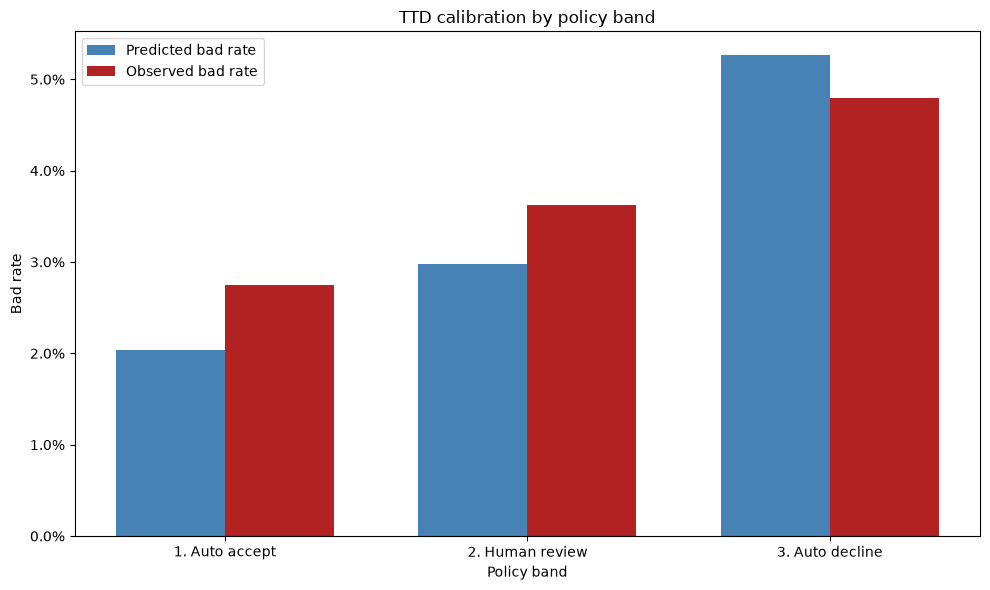

In [27]:
plot_data = band_calibration.copy()

band_order = [
    "1. Auto accept",
    "2. Human review",
    "3. Auto decline",
]

plot_data["policy_band"] = pd.Categorical(
    plot_data["policy_band"],
    categories=band_order,
    ordered=True,
)

plot_data = plot_data.sort_values("policy_band")

x = np.arange(len(plot_data))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    plot_data["Predicted bad rate"],
    width,
    label="Predicted bad rate",
    color="steelblue",
)

ax.bar(
    x + width / 2,
    plot_data["Observed bad rate"],
    width,
    label="Observed bad rate",
    color="firebrick",
)

ax.set_xticks(x)
ax.set_xticklabels(plot_data["policy_band"])
ax.set_ylabel("Bad rate")
ax.set_xlabel("Policy band")
ax.set_title("TTD calibration by policy band")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value:.1%}")
)
ax.legend()

plt.tight_layout()
plt.show()

---

# Robustness testing

In [28]:
REVIEW_ACCURACY = 0.90
RANDOM_SEED = 20261005

ttd = policy_sample.copy()

# Use the observed outcome saved by notebook 16.
outcome_column = (
    "observed_bad"
    if "observed_bad" in ttd.columns
    else "kigb_bad"
)

required = ["predicted_pd", outcome_column]
if ttd[required].isna().any().any():
    raise ValueError("Missing PD or observed outcome.")

if not ttd["predicted_pd"].between(0, 1).all():
    raise ValueError("Predicted PD must be between 0 and 1.")

if not ttd[outcome_column].isin([0, 1]).all():
    raise ValueError("Observed outcome must be 0 or 1.")

auto_accept = ttd["predicted_pd"] < 0.025
refer = ttd["predicted_pd"].between(0.025, 0.035, inclusive="both")

# A correct review accepts an observed good and declines an observed bad.
# An incorrect review makes the opposite decision.
rng = np.random.default_rng(RANDOM_SEED)
review_correct = rng.random(len(ttd)) < REVIEW_ACCURACY

accepted_after_review = (
    refer
    & (
        (review_correct & ttd[outcome_column].eq(0))
        | (~review_correct & ttd[outcome_column].eq(1))
    )
)

accepted = auto_accept | accepted_after_review
accepted_ttd = ttd.loc[accepted]

if accepted_ttd.empty:
    raise ValueError("No applicants were accepted.")

policy_summary_90 = pd.DataFrame({
    "Measure": [
        "Total applicants",
        "Accepted applicants",
        "Declined applicants",
        "Approval rate",
        "Predicted accepted bad rate",
        "Observed accepted bad rate",
        "Accepted expected bads",
        "Accepted observed bads",
        "Applicants sent to review",
        "Review rate",
    ],
    "Value": [
        len(ttd),
        int(accepted.sum()),
        int((~accepted).sum()),
        accepted.mean(),
        accepted_ttd["predicted_pd"].mean(),
        accepted_ttd[outcome_column].mean(),
        accepted_ttd["predicted_pd"].sum(),
        int(accepted_ttd[outcome_column].sum()),
        int(refer.sum()),
        refer.mean(),
    ],
})

policy_summary_90

,Measure,Value
0,Total applicants,"2,000.0000"
1,Accepted applicants,982.0000
2,Declined applicants,"1,018.0000"
3,Approval rate,0.4910
4,Predicted accepted bad rate,0.0263
5,Observed accepted bad rate,0.0102
6,Accepted expected bads,25.8061
7,Accepted observed bads,10.0000
8,Applicants sent to review,718.0000
9,Review rate,0.3590
